Create monthly QA-filtered burned fractions from native MCD64A1 HDF tiles.

The script processes one month at a time so that temporary tile masks and
mosaics never accumulate for the full 2001--2022 archive. It requires the GDAL
command-line programs, including gdal_calc.py.

In [36]:
from __future__ import annotations

# import calendar
# import importlib.util
import re
# import shutil
# import subprocess
# import sys
# import tempfile
from osgeo import gdal
from pathlib import Path
from pyproj import CRS, Transformer
# import datetime as dt
import numpy as np
import pandas as pd
import xarray as xr

DATE_RE = re.compile(r"\.A(?P<year>\d{4})(?P<doy>\d{3})\.")



In [37]:
def group_granules(input_dir: Path) -> list[Path]:
    groups: list[Path] = []
    for path in input_dir.rglob(pattern='*.hdf'):
        groups.append(path.resolve())
    return groups

MOD14A1_DATA_DIR = Path('../../../modis_mod14a1/download/')
MYD14A1_DATA_DIR = Path('../../../modis_myd14a1/download/')

grouped_mod14a1 = group_granules(MOD14A1_DATA_DIR)
grouped_myd14a1 = group_granules(MYD14A1_DATA_DIR)

In [38]:
ds = gdal.Open(grouped_mod14a1[1])
# print(ds.GetSubDatasets())
for name, desc in ds.GetSubDatasets():
    if "FireMask" in name:
        fire_ds = gdal.Open(name)
        fire_mask = fire_ds.ReadAsArray()
        break

modis_crs = CRS.from_wkt(fire_ds.GetProjection())
wgs84 = CRS.from_epsg(4326)

transformer = Transformer.from_crs(
    modis_crs,
    wgs84,
    always_xy=True
)
# print(fire_mask.shape)

In [39]:
filename = grouped_mod14a1[1]

match = re.search(r"\.A(\d{4})(\d{3})\.", str(filename))
year = int(match.group(1))
doy = int(match.group(2))

start_date = pd.Timestamp(year=year, month=1, day=1) + pd.Timedelta(days=doy - 1)

time = pd.date_range(
    start=start_date,
    periods=fire_mask.shape[0],
    freq="D"
)

time

gt = fire_ds.GetGeoTransform()
nx = fire_ds.RasterXSize
ny = fire_ds.RasterYSize

x = gt[0] + (np.arange(nx) + 0.5) * gt[1]
y = gt[3] + (np.arange(ny) + 0.5) * gt[5]

xx, yy = np.meshgrid(x ,y)
lon, lat = transformer.transform(xx, yy)

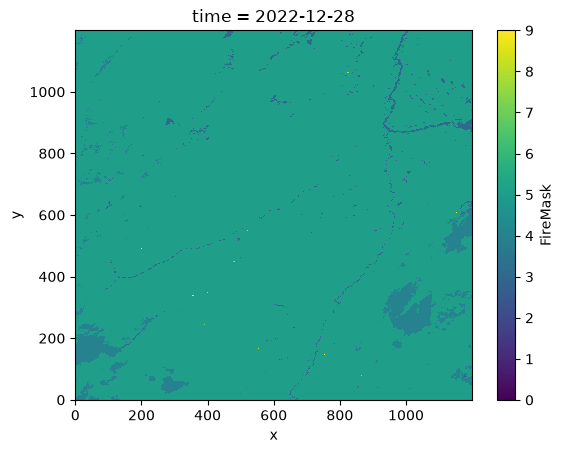

In [47]:
da = xr.DataArray(
    fire_mask,
    dims=["time", "y", "x"],
    coords={
        "time": time,
        # "x": lon,
        # "y": lat,
    },
    name="FireMask"
)

da = da.assign_coords(
    lon=(("y", "x"), lon),
    lat=(("y", "x"), lat),
)

da.isel(time=1).plot()